DATA CLEANING WITH PANDAS

In this notebook i will try to summarize the data cleaning process using the pandas library in Python.  
the notebook is based on the original NB we used in class, but i will try to make it more concise and to the point.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

I will work with the csv files localy, but in the commeted code you can see how to read the csv files from the web.

In [2]:
# # orders.csv
#url = "https://drive.google.com/file/d/1Vu0q91qZw6lqhIqbjoXYvYAQTmVHh6uZ/view?usp=sharing"
#path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
#orders= pd.read_csv(path)
orders = pd.read_csv('/Users/r/Documents/VS/Py_A_Pa/Eniac/data/orders.csv')

# # orderlines.csv
# url = "https://drive.google.com/file/d/1FYhN_2AzTBFuWcfHaRuKcuCE6CWXsWtG/view?usp=sharing"
# path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
# orderlines = pd.read_csv(path)
orderlines = pd.read_csv('/Users/r/Documents/VS/Py_A_Pa/Eniac/data/orderlines.csv')

# # products.csv
# url = "https://drive.google.com/file/d/1_8hQE61X66Jt7c7gbsFqIoNV6CaonZ0y/view?usp=share_link"
# path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
# orderlines = pd.read_csv(path)
products = pd.read_csv('/Users/r/Documents/VS/Py_A_Pa/Eniac/data/products.csv')

# # brands.csv
# url = "https://drive.google.com/file/d/1RpWpSSwe7PPskdpf72kaJ6zsX5jc835k/view?usp=share_link"
# path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
# brands = pd.read_csv(path)
brands = pd.read_csv('/Users/r/Documents/VS/Py_A_Pa/Eniac/data/brands.csv')

Before we begin, let's create a copy of all DataFrames.

In [3]:
orders_df = orders.copy()
orderlines_df = orderlines.copy()
products_df = products.copy()
brands_df = brands.copy()

In [121]:
#orders_df
# orderlines_df
# products_df
# brands_df

GENERAL INFORMATION

In [4]:
#information on the columns names, intressting only if we want to merge df.
orders_df.columns, orderlines_df.columns, products_df.columns,brands_df.columns

(Index(['order_id', 'created_date', 'total_paid', 'state'], dtype='str'),
 Index(['id', 'id_order', 'product_id', 'product_quantity', 'sku', 'unit_price',
        'date'],
       dtype='str'),
 Index(['sku', 'name', 'desc', 'price', 'promo_price', 'in_stock', 'type'], dtype='str'),
 Index(['short', 'long'], dtype='str'))

In [123]:
#orders_df["created_date"] = pd.to_datetime(orders_df["created_date"])
# #orders_df= orders_df.set_index('created_date')
# orders_df.info()
# states = {'Cancelled' :1, 
#           'Completed' :2,
#           'Pending' :3,
#           'Shopping Basket' :4,
#           'Place Order' :5
#           }
# orders_df.state.map(states).value_counts()


In [124]:
# 1. Make sure created_date is datetime
#orders_df['created_date'] = pd.to_datetime(orders_df['created_date'])
# 2. Set as index for resampling
#orders_df = orders_df.set_index('created_date')
# 3. Resample by day, count orders per status
# status_over_time = (
#     orders_df.groupby('state')
#     .resample('D')['order_id']
#     .count()
#     .unstack(level=0)  # states become columns
#     .fillna(0)
# )
# # 4. Plot
# status_over_time.plot(
#     figsize=(14, 6),
#     title='Order Statuses Over Time (Daily)',
#     xlabel='Date',
#     ylabel='Number of Orders'
# )
# plt.legend(title='Status')
# plt.tight_layout()
# plt.show()

In [125]:
# orders_df['created_date'] = pd.to_datetime(orders_df['created_date'])
# orders_df = orders_df.set_index('created_date')

# status_over_time = (
#     orders_df.groupby('state')
#     .resample('D')['order_id']
#     .count()
#     .unstack(level=0)
#     .fillna(0)
# )

# # Plot with explicit column names as labels
# fig, ax = plt.subplots(figsize=(14, 6))

# for col in status_over_time.columns:
#     ax.plot(status_over_time.index, status_over_time[col], label=col)

# ax.set_title('Order Statuses Over Time (Daily)')
# ax.set_xlabel('Date')
# ax.set_ylabel('Number of Orders')
# ax.legend(title='Status')
# plt.tight_layout()
# plt.show()

In [126]:
# # Normalize each day to 100% to see share shifts

# # Define mapping explicitly
# status_labels = {
#     'Cancelled': 'Cancelled',
#     'Completed': 'Completed',
#     'Pending': 'Pending',
#     'Place Order': 'Place Order',
#     'Shopping Basket': 'Shopping Basket'
# }

# # Verify columns match exactly
# print("Columns in plot data:", status_over_time.columns.tolist())
# print("Expected statuses:   ", list(status_labels.keys()))

# # Check for hidden characters or whitespace — common culprit!
# print("\nRaw values with repr:")
# for val in orders_df['state'].unique():
#     print(repr(val))
    
# status_pct = status_over_time.div(status_over_time.sum(axis=1), axis=0) * 100

# fig, ax = plt.subplots(figsize=(14, 6))
# status_pct.plot.area(ax=ax, alpha=0.7)
# ax.set_title('Order Status Share Over Time (Daily %)')
# ax.set_xlabel('Date')
# ax.set_ylabel('% of Orders')
# ax.legend(title='Status')
# plt.tight_layout()
# plt.show()

# status_labels = {
#     'Cancelled': 'Cancelled',
#     'Completed': 'Completed',
#     'Pending': 'Pending',
#     'Place Order': 'Place Order',
#     'Shopping Basket': 'Shopping Basket'
# }

# # Verify columns match exactly
# print("Columns in plot data:", status_over_time.columns.tolist())
# print("Expected statuses:   ", list(status_labels.keys()))


In [127]:
# # Define mapping explicitly
# status_labels = {
#     'Cancelled': 'Cancelled',
#     'Completed': 'Completed',
#     'Pending': 'Pending',
#     'Place Order': 'Place Order',
#     'Shopping Basket': 'Shopping Basket'
# }

# # Verify columns match exactly
# print("Columns in plot data:", status_over_time.columns.tolist())
# print("Expected statuses:   ", list(status_labels.keys()))

# # Check for hidden characters or whitespace — common culprit!
# print("\nRaw values with repr:")
# for val in orders_df['state'].unique():
#     print(repr(val))

In [128]:
### Problem with the labels as we used to normalize!!!!
# data = orders_df.state.value_counts(normalize=True)
# labels = orders_df.state.unique()
# # define Seaborn color palette to use
# colors = sns.color_palette('bright')

# # plotting data on chart
# plt.pie(data, labels=labels, colors=colors, autopct='%1.1f%%')
# plt.show()
# # Compare raw row counts vs what the area chart shows
# print("Raw value_counts:")
# print(orders_df['state'].value_counts(normalize=True).round(3))

# print("\nWhat the area chart sees (mean daily share):")
# print(status_over_time.div(status_over_time.sum(axis=1), axis=0).mean().round(3))

In [129]:
 
# mean_share = status_over_time.div(status_over_time.sum(axis=1), axis=0).mean()

# plt.pie(mean_share, labels=mean_share.index, autopct='%1.1f%%',
#         colors=sns.color_palette('bright'))
# plt.title('Average Daily Order Status Share')
# plt.show()

## 1.&nbsp; Duplicates
We can check for duplicates using the pandas [.duplicated()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html) method.

We can then delete these rows, if we wish, using [.drop_duplicates()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html)

In [5]:
# orders_df
orders_df.duplicated().sum()

np.int64(0)

In [6]:
# orderlines_df
orderlines_df.duplicated().sum()

np.int64(0)

In [7]:
# brands_df
brands_df.duplicated().sum()

np.int64(0)

In [11]:
#products_df.info()
products_df.duplicated().sum()

np.int64(0)

removed the duplicates from the DataFrame and reset the index.

In [9]:
products_df= products_df.drop_duplicates()
products_df.duplicated().sum()

np.int64(0)

In [135]:
#products_df["price"] = pd.to_numeric(products_df["price"], errors="coerce")

In [136]:
#products_df.groupby(['sku']).price.count().sort_values(ascending=False)

In [137]:
#products_df.groupby(['sku']).agg({'price': [min, max, 'mean']})#.plot.line()

We have no duplicate rows in either DataFrame. Easy, there is no problem to solve. Normally though, if there were some duplicates, we'd drop the extra rows.

## 2.&nbsp; `.info()`

This text was placed at the very beginning of the original NB, but the .info() method was called first here, so i moved the text. 
In my opinion we should satrt with info and repeat it after each step of cleaning, but it's up to you.


One of the best ways to begin data cleaning is by exploring using `.info()`. This will tell us:
* The shape of the DataFrame
* The names of the columns
* If there are any missing values
* The datatypes of the columns

By exploring the missing values and correcting any incorrect datatypes, we often come across inconsistencies in our data.

Beyond this, we should also have a **check for any duplicate rows**.

Let's first deal with the duplicates, as it's nice and easy, then we'll explore what `.info()` has to tell us.

In [12]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 226909 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      226909 non-null  int64  
 1   created_date  226909 non-null  str    
 2   total_paid    226904 non-null  float64
 3   state         226909 non-null  str    
dtypes: float64(1), int64(1), str(2)
memory usage: 6.9 MB


* `total_paid` has 5 missing values
* `created_date` should become datetime datatype. 

!!! It should be noted that we can use the `pd.to_datetime()` function to convert it to datetime, but if we save the data to a csv file and read it again, it will be read as an object datatype, so we will have to convert it again. this is something to keep in mind when working with datetime data.

In [14]:
orderlines_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56869 entries, 0 to 56868
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        56869 non-null  int64  
 1   id                56869 non-null  int64  
 2   id_order          56869 non-null  int64  
 3   product_id        56869 non-null  int64  
 4   product_quantity  56869 non-null  int64  
 5   sku               56869 non-null  str    
 6   unit_price        56869 non-null  float64
 7   date              56869 non-null  str    
dtypes: float64(1), int64(5), str(2)
memory usage: 3.5 MB


* `date` should be a datetime datatype
* `unit_price` should be a float datatype

## 3.&nbsp; Missing values

### 3.1.&nbsp; Orders
* `total_paid` has 5 missing values

In [15]:
orders_df['total_paid'].isna().sum()

np.int64(5)

In [16]:
orders_df.shape[0]

226909

In [17]:
num_missing = orders_df['total_paid'].isna().sum()
total_rows = orders_df.shape[0]
percent_missing = (100 * num_missing / total_rows)
print(f"5 missing values represents {percent_missing:.5f}% of the rows in our DataFrame")

5 missing values represents 0.00220% of the rows in our DataFrame


As there is such a tiny amount of missing values, we will simply delete these rows, as we have enough data without them.

In [18]:
orders_df = orders_df.dropna(axis=0)

Should you have a significant number of missing values in the future, you have a choice:
+ you can impute the values
+ you can take the values from other DataFrames if they are redundantly stored
+ you can delete the rows or columns
+ or any number of other creative solutions

Please, always consider how much time you have on your project, and what impact your method of choice will have on your final assesment.

In [19]:
orders_df.shape, orderlines_df.shape

((226904, 4), (56869, 8))

### 3.2.&nbsp; Orderlines
There are no missing values in `orderlines_df`

In [20]:
orderlines_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56869 entries, 0 to 56868
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        56869 non-null  int64  
 1   id                56869 non-null  int64  
 2   id_order          56869 non-null  int64  
 3   product_id        56869 non-null  int64  
 4   product_quantity  56869 non-null  int64  
 5   sku               56869 non-null  str    
 6   unit_price        56869 non-null  float64
 7   date              56869 non-null  str    
dtypes: float64(1), int64(5), str(2)
memory usage: 3.5 MB


In [147]:
orderlines_df.isna().sum()

Unnamed: 0          0
id                  0
id_order            0
product_id          0
product_quantity    0
sku                 0
unit_price          0
date                0
dtype: int64

### 3.3.&nbsp; Products
In `products_df` there are 46 missing values in `price` and 50 in `type`

In [14]:
products_df.info()
products_df.isna().sum()

<class 'pandas.DataFrame'>
Index: 10580 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   sku          10580 non-null  str  
 1   name         10580 non-null  str  
 2   desc         10573 non-null  str  
 3   price        10534 non-null  str  
 4   promo_price  10580 non-null  str  
 5   in_stock     10580 non-null  int64
 6   type         10530 non-null  str  
dtypes: int64(1), str(6)
memory usage: 661.2 KB


sku             0
name            0
desc            7
price          46
promo_price     0
in_stock        0
type           50
dtype: int64

### 3.4.&nbsp; Brands
There are no missing values in `brands_df`

In [15]:
brands_df.isna().sum()

short    0
long     0
dtype: int64

## 4.&nbsp; Datatypes

### 4.1.&nbsp; Orders
* `created_date` should become datetime datatype

In [148]:
orders_df.columns

Index(['order_id', 'created_date', 'total_paid', 'state'], dtype='str')

In [149]:
orders_df["created_date"] = pd.to_datetime(orders_df["created_date"])

In [150]:
orders_df.info()

<class 'pandas.DataFrame'>
Index: 226904 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      226904 non-null  int64         
 1   created_date  226904 non-null  datetime64[us]
 2   total_paid    226904 non-null  float64       
 3   state         226904 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 8.7 MB


### 4.1.&nbsp; Orderlines
* `date` should be a datetime datatype
* `unit_price` should be a float datatype

#### 4.1.1.&nbsp; `date`

In [151]:
orderlines_df["date"] = pd.to_datetime(orderlines_df["date"])

In [152]:
orderlines_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56869 entries, 0 to 56868
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Unnamed: 0        56869 non-null  int64         
 1   id                56869 non-null  int64         
 2   id_order          56869 non-null  int64         
 3   product_id        56869 non-null  int64         
 4   product_quantity  56869 non-null  int64         
 5   sku               56869 non-null  str           
 6   unit_price        56869 non-null  float64       
 7   date              56869 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(5), str(1)
memory usage: 3.5 MB


#### 4.1.2.&nbsp;`unit_price`

In [ ]:
#This line is commented in order to ensure complete cleaning if NB is used with `Run All`
# orderlines_df["unit_price"] = pd.to_numeric(orderlines_df["unit_price"])

As you can see when we try to convert `unit_price` to a numerical datatype, we receive a `ValueError` telling us that pandas doesn't understand the number `1.137.99`. This is probably because numbers cannot have multiple decimal points. Let's see if there are any other numbers like this:

> `.` is a wildcard in regex, we need the `\` as an escape

In [17]:
# Count the number of decimal points in the unit_price
orderlines_df['unit_price'].str.count(r"\.").value_counts()

unit_price
1    257814
2     36169
Name: count, dtype: int64

Looks like over 36000 rows in `orderlines` are affected by this problem. Let's work out how much that is as a percentage of our total data.

In [ ]:
orderlines_df.loc[(orderlines_df['unit_price'].str.count(r"\.")>1)].sample(3)

AttributeError: Can only use .str accessor with string values, not floating

In [ ]:
# Count the rows with more than one `.`
mult_decimal_rows = (orderlines_df['unit_price'].str.count(r"\.")>1).sum()

# Find the percentage of corrupted rows
percent_corrupted = (100 * mult_decimal_rows / orderlines_df.shape[0])
print(f"{percent_corrupted:.2f}% of the rows in our orderlines DataFrame have multiple decimal points in the unit_price")

12.30% of the rows in our orderlines DataFrame have multiple decimal points in the unit_price


This is a bit of a tricky decision as 12.3% is a significant amount of our data... and we might even end up losing a larger portion of our data than this too. For the moment we will delete the rows as we only have 2 weeks for this project and I'd like some quick, accurate results to show. If we have time at the end, we can come back and investigate this problem further, maybe there's a solution?

Each row of `orderlines` represents a product in an order. For example, if order number 175 contained 3 seperate products, then order 175 would have 3 rows in `orderlines`, one row for each of the products. If 2 of those products have 'normal' prices (14.99, 15.85) and 1 has a price with 2 decimal points (1.137.99), we need to remove the whole order and not just the affected row. If we only remove the row with 2 decimal places then any later analysis about products and prices could be misleading.

We therefore need to find the order numbers associated with the rows that have 2 decimal points, and then remove all the associated rows.

In [ ]:
# Boolean mask to find the orders that contain a price with multiple decimal points
multiple_decimal_mask = orderlines_df['unit_price'].str.count(r"\.") > 1

# Apply the boolean mask to the orderlines DataFrame. This way we can find the order_id of all the affected orders.
corrupted_order_ids = orderlines_df.loc[multiple_decimal_mask, "id_order"]

# Keep only the rows that do not have multiple decimal points
orderlines_df = orderlines_df.loc[~orderlines_df['id_order'].isin(corrupted_order_ids)]

In [ ]:
orderlines_df.shape[0]

216250

**We** still have 216250 rows in orderlines to work with. This should be more than enough for our evaluation.

Now that all of the 2 decimal point prices have been removed, let's try again to convert the column `unit_price` to the correct datatype.

In [ ]:
orderlines_df["unit_price"] = pd.to_numeric(orderlines_df["unit_price"])

It worked perfectly

In [ ]:
orderlines_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 216250 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                216250 non-null  int64         
 1   id_order          216250 non-null  int64         
 2   product_id        216250 non-null  int64         
 3   product_quantity  216250 non-null  int64         
 4   sku               216250 non-null  object        
 5   unit_price        216250 non-null  float64       
 6   date              216250 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 13.2+ MB


In [ ]:
# double check / clean / synchronise non-corrupted id_orders in orders_df
# discuss the state of an order in orders_df
# renaming columns
# date problem in orderlines_df

## Challenge: Clean the `products` DataFrame
Now it's your turn. Use the lessons you learnt above and clean the products DataFrame. You don't have to copy exactly what we did. Think about the consequences of your actions, sometimes it is ok to delete rows, other times you may wish to come up with more creative solutions.

In [ ]:
# products.csv
url = "https://drive.google.com/file/d/1afxwDXfl-7cQ_qLwyDitfcCx3u7WMvkU/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products = pd.read_csv(path)

In [ ]:
products_df = products.copy()

In [ ]:
# your code here
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19326 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sku          19326 non-null  object
 1   name         19326 non-null  object
 2   desc         19319 non-null  object
 3   price        19280 non-null  object
 4   promo_price  19326 non-null  object
 5   in_stock     19326 non-null  int64 
 6   type         19276 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.0+ MB


- price and promo price are wrong type
- there are nan values in desc, price, type

In [ ]:
products_df.describe()

,in_stock
count,19326.000000
mean,0.109593
std,0.312390
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


### Look for Duplicates

In [ ]:
# your code here
products_df.duplicated().sum()

np.int64(8746)

In [ ]:
products_df.drop_duplicates(inplace=True)

In [ ]:
products_df.duplicated().sum()

np.int64(0)

In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10580 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sku          10580 non-null  object
 1   name         10580 non-null  object
 2   desc         10573 non-null  object
 3   price        10534 non-null  object
 4   promo_price  10580 non-null  object
 5   in_stock     10580 non-null  int64 
 6   type         10530 non-null  object
dtypes: int64(1), object(6)
memory usage: 661.2+ KB


In [ ]:
products_df.sample(5)

,sku,name,desc,price,promo_price,in_stock,type
14853,STA0049,Startech USB-C Adapter USB 3.1 Gigabit Etherne...,USB-C adapter cable (compatible with Thunderbo...,70.99,529.895,0,12585395
14564,SAT0021,Support Satechi iPhone Aluminum Silver,Stand with aluminum finish Lightning access to...,34.99,249.901,1,5720
409,PAC0274,NewerTech miniStack Mac 2TB Hard Drive,External box Mac + 2TB Hard Drive.,179.98,1.579.897,0,11935397
17634,APP2517,Apple Silicon Case iPhone Case 8 Plus / 7 Plus...,Ultrathin silicone case and microfiber premium...,45,429.998,1,11865403
13180,PAC1685,Pack QNAP TS-251A NAS Server | 2GB RAM | Seaga...,NAS with 2GB of RAM and 16TB (2x8TB) Seagate I...,1069.67,7.511.789,0,12175397


In [ ]:
products_df.loc[products_df["sku"].duplicated(keep=False)]

,sku,name,desc,price,promo_price,in_stock,type
7992,APP1197,"Apple iMac 21.5 ""Core i5 31 GHz Retina display...",Desktop Apple iMac 21.5 inch i5 31 GHz Retina ...,1729,1305.59,0,1282
8000,APP1197,"Apple iMac 21.5 ""Core i5 31 GHz Retina display...",Desktop Apple iMac 21.5 inch i5 31 GHz Retina ...,NaN,1305.59,0,1282


In [ ]:
products_df.drop_duplicates(subset=["sku"], inplace=True)

In [ ]:
products_df.loc[products_df["sku"].duplicated(keep=False)]

,sku,name,desc,price,promo_price,in_stock,type


In [ ]:
products_df.shape

(10579, 7)

### Look for Missing values


In [ ]:
products_df.isna().sum()

,0
sku,0
name,0
desc,7
price,45
promo_price,0
in_stock,0
type,50


In [ ]:
# your code here
products_df["price"].isna().value_counts()

,count
price,
False,10534
True,45


In [ ]:
products_df.sample(5)

,sku,name,desc,price,promo_price,in_stock,type
16914,APP2167,"Apple iPad Leather Smart Cover Case Pro ""Candy...",Intelligent quality leather case with function...,85,789.997,0,12635403
1793,SAN0068,SanDisk Ultra II SSD 120GB Drive,SATA III SSD hard disk (6Gb / s) 120GB for Mac...,87,698.993,0,12215397
13608,DLL0038-A,"(Open) Dell Monitor P4317Q 425 """" IPS 4K DP mD...",425 inch monitor for Mac,1166.44,9.712.267,0,1298
18618,SAT0067,Satechi USB 3.0 Hub Adapter 10/100/1000 Gigabi...,Satechi adapter ranging from USB 3.0 to Gigabi...,19.99,169.896,1,12585395
18953,GTE0134,G-Technology G-SPEED XL 48TB RAID Thunderbolt ...,External Storage 48TB and Thunderbolt 3 Connec...,5106.99,41.999.947,0,11935397


In [ ]:
products_df.loc[products_df['desc'].isna()]

,sku,name,desc,price,promo_price,in_stock,type
16126,WDT0211-A,"Open - Purple 2TB WD 35 ""PC Security Mac hard ...",NaN,107,814.659,0,1298
16128,APP1622-A,Open - Apple Smart Keyboard Pro Keyboard Folio...,NaN,1.568.206,1.568.206,0,1298
17843,PAC2334,Synology DS718 + NAS Server | 10GB RAM,NaN,566.35,5.659.896,0,12175397
18152,KAN0034-A,Open - Kanex USB-C Gigabit Ethernet Adapter Ma...,NaN,29.99,237.925,0,1298
18490,HTE0025,Hyper Pearl 1600mAh battery Mini USB Mirror an...,NaN,24.99,22.99,1,1515
18612,OTT0200,OtterBox External Battery Power Pack 20000 mAHr,NaN,79.99,56.99,1,1515
18690,HOW0001-A,Open - Honeywell thermostat Lyric zonificador ...,NaN,199.99,1.441.174,0,11905404


In [ ]:
products_df.loc[products_df['desc'].isna(), "desc"] = products_df.loc[products_df['desc'].isna(), "name"]

In [ ]:
products_df.loc[products_df['desc'].isna()]

,sku,name,desc,price,promo_price,in_stock,type


In [ ]:
products_df.loc[products_df['type'].isna()]

,sku,name,desc,price,promo_price,in_stock,type
307,SAN0017,SanDisk Cruzer Edge USB 2.0 Flash Drive 16GB,Pendrive USB 2.0 Mac and PC.,8,59.895,0,NaN
530,SAN0026,SanDisk Extreme Cruzer 16GB USB 3.0 Flash Drive,USB 3.0 flash drive 16GB USB Mac and PC.,22,209.935,0,NaN
792,APP0672,Apple iPhone 5S 16GB Space Gray,New iPhone 5S 16G Libre (ME432Y / AB).,4.694.994,4.694.994,0,NaN
797,APP0673,Apple iPhone 5S 16GB Silver,New Free iPhone 5S 16GB (ME433Y / A).,4.090.042,4.090.042,0,NaN
798,APP0675,Apple iPhone 5S 32GB Space Gray,New Free iPhone 5S 32GB (ME435Y / A).,559,3.989.975,0,NaN
1193,APP0823,Apple iPhone 6 16GB Silver,New iPhone 6 16GB Free (MG482QL / A).,639,639.001,0,NaN
1199,APP0829,Apple iPhone 6 Plus 16GB Silver,New iPhone 6 Plus 16G Free (MGA92QL / A).,749,7.490.021,0,NaN
1200,APP0822,Apple iPhone 6 16GB Space Gray,New iPhone 6 16GB Free (MG472QL / A).,639,639.001,0,NaN
1201,APP0825,Apple iPhone 6 64GB Space Gray,New iPhone 6 64GB Free (MG4F2QL / A).,749,7.490.021,0,NaN
1202,APP0826,Apple iPhone 6 64GB Silver,New iPhone 6 64GB Free (MG4H2QL / A).,749,7.503.331,0,NaN


In [ ]:
products_df["type"] = products_df["type"].fillna("unknown")

In [ ]:
products_df.loc[products_df['type'].isna()]

,sku,name,desc,price,promo_price,in_stock,type


In [ ]:
products_df.loc[products_df["price"].isna()].head(3)

,sku,name,desc,price,promo_price,in_stock,type
34,TWS0019,Twelve South MagicWand support Apple Magic Tra...,MagicWand for wireless keyboard and Magic Trac...,NaN,299.899,0,8696
1900,AII0008,Aiino Case MacBook Air 11 '' Transparent,MacBook Air 11-inch casing with matte finish.,NaN,22.99,0,13835403
2039,CEL0020,Celly Ambo Luxury Leather Case + iPhone 6 Case...,Cover and housing together with magnet for iPh...,NaN,399.905,0,11865403


In [ ]:
products_df = products_df.dropna(subset=['price'])

### Check / Change Data types

In [ ]:
# your code here
products_df.dtypes

,0
sku,object
name,object
desc,object
price,object
promo_price,object
in_stock,int64
type,object


In [ ]:
#products_df["price"] = pd.to_numeric(products_df["price"])

In [ ]:
# (orderlines_df['unit_price'].str.count(r"\.")>1)
products_df.loc[products_df["price"].str.count(r"\.") > 1]

,sku,name,desc,price,promo_price,in_stock,type
665,CRU0015-2,Crucial memory Mac 16GB (2x8GB) SO-DIMM DDR3 1...,RAM 16GB (2x8GB) 135V MacBook Pro iMac (2012/2...,1.639.792,1.629.894,1,1364
792,APP0672,Apple iPhone 5S 16GB Space Gray,New iPhone 5S 16G Libre (ME432Y / AB).,4.694.994,4.694.994,0,unknown
797,APP0673,Apple iPhone 5S 16GB Silver,New Free iPhone 5S 16GB (ME433Y / A).,4.090.042,4.090.042,0,unknown
827,PAC0339,NewerTech miniStack 4TB Hard Drive Mac,External Box Hard Drive Mac + 4TB.,2.199.791,2.199.901,0,11935397
885,PAC0376,OWC Mercury Elite Pro Dual Thunderbolt + 8TB,RAID outer box 35 inch SATA connection Thunder...,5.609.698,5.549.895,0,11935397
...,...,...,...,...,...,...,...
19312,REP0424,Input repair Headphones iPad,Repair service including parts and labor for iPad,6.999.003,69.99,0,"1,44E+11"
19313,REP0421,iPad charging connector repair,Repair service including parts and labor for iPad,6.999.003,69.99,0,"1,44E+11"
19314,REP0416,iPad front camera repair,Repair service including parts and labor for iPad,6.999.003,69.99,0,"1,44E+11"
19315,REP0413,repair rear camera iPad,Repair service including parts and labor for iPad,6.999.003,69.99,0,"1,44E+11"


In [ ]:
products_df.loc[products_df["price"].str.contains(r"\d+\.\d+\.\d+")].head(3)

,sku,name,desc,price,promo_price,in_stock,type
665,CRU0015-2,Crucial memory Mac 16GB (2x8GB) SO-DIMM DDR3 1...,RAM 16GB (2x8GB) 135V MacBook Pro iMac (2012/2...,1.639.792,1.629.894,1,1364
792,APP0672,Apple iPhone 5S 16GB Space Gray,New iPhone 5S 16G Libre (ME432Y / AB).,4.694.994,4.694.994,0,unknown
797,APP0673,Apple iPhone 5S 16GB Silver,New Free iPhone 5S 16GB (ME433Y / A).,4.090.042,4.090.042,0,unknown


In [ ]:
products_df = products_df.loc[(~products_df["price"].str.contains(r"\d+\.\d+\.\d+"))&(~products_df["price"].str.contains(r"\d+\.\d{3,}")), :]

In [ ]:
products_df["price"] = pd.to_numeric(products_df["price"])

In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9992 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku          9992 non-null   object 
 1   name         9992 non-null   object 
 2   desc         9992 non-null   object 
 3   price        9992 non-null   float64
 4   promo_price  9992 non-null   object 
 5   in_stock     9992 non-null   int64  
 6   type         9992 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 624.5+ KB


---

promo_price column

In [ ]:
(products_df["promo_price"].str.contains(r"\d+\.\d+\.\d+") | (products_df["promo_price"].str.contains(r"\d+\.\d{3,}"))).value_counts(normalize=True)

,proportion
promo_price,
True,0.923939
False,0.076061


# 3_WORKING WITH DATETIMES & GROUPING DATA

In [ ]:
# orders_cl.csv
url = "https://drive.google.com/file/d/1Tla62vfu__kCqvgypZyVt2S9VuC016yH/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)

In [ ]:
orders_df=orders_cl.copy()

In [ ]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226904 entries, 0 to 226903
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      226904 non-null  int64  
 1   created_date  226904 non-null  object 
 2   total_paid    226904 non-null  float64
 3   state         226904 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.9+ MB


In [ ]:
orders_df["created_date"] = pd.to_datetime(orders_df["created_date"])

In [ ]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226904 entries, 0 to 226903
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      226904 non-null  int64         
 1   created_date  226904 non-null  datetime64[ns]
 2   total_paid    226904 non-null  float64       
 3   state         226904 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 6.9+ MB


In [ ]:
orders_df.head()

,order_id,created_date,total_paid,state
0,241319,2017-01-02 13:35:40,44.99,Cancelled
1,241423,2017-11-06 13:10:02,136.15,Completed
2,242832,2017-12-31 17:40:03,15.76,Completed
3,243330,2017-02-16 10:59:38,84.98,Completed
4,243784,2017-11-24 13:35:19,157.86,Cancelled


In [ ]:
single_column = orders_df["created_date"]

type(single_column)

pandas.core.series.Series

In [ ]:
orders_df.loc[:,"month"] = orders_df["created_date"].dt.month
orders_df.head()

,order_id,created_date,total_paid,state,month
0,241319,2017-01-02 13:35:40,44.99,Cancelled,1
1,241423,2017-11-06 13:10:02,136.15,Completed,11
2,242832,2017-12-31 17:40:03,15.76,Completed,12
3,243330,2017-02-16 10:59:38,84.98,Completed,2
4,243784,2017-11-24 13:35:19,157.86,Cancelled,11


In [ ]:
orders_df.loc[:,"month_name"] = orders_df["created_date"].dt.month_name()
orders_df.head()

,order_id,created_date,total_paid,state,month,month_name
0,241319,2017-01-02 13:35:40,44.99,Cancelled,1,January
1,241423,2017-11-06 13:10:02,136.15,Completed,11,November
2,242832,2017-12-31 17:40:03,15.76,Completed,12,December
3,243330,2017-02-16 10:59:38,84.98,Completed,2,February
4,243784,2017-11-24 13:35:19,157.86,Cancelled,11,November


In [ ]:
orders_df.loc[:,"year"] = orders_df["created_date"].dt.year
orders_df.head()

,order_id,created_date,total_paid,state,month,month_name,year
0,241319,2017-01-02 13:35:40,44.99,Cancelled,1,January,2017
1,241423,2017-11-06 13:10:02,136.15,Completed,11,November,2017
2,242832,2017-12-31 17:40:03,15.76,Completed,12,December,2017
3,243330,2017-02-16 10:59:38,84.98,Completed,2,February,2017
4,243784,2017-11-24 13:35:19,157.86,Cancelled,11,November,2017


In [ ]:
orders_df.loc[:,"day"] = orders_df["created_date"].dt.day
orders_df.head()

,order_id,created_date,total_paid,state,month,month_name,year,day
0,241319,2017-01-02 13:35:40,44.99,Cancelled,1,January,2017,2
1,241423,2017-11-06 13:10:02,136.15,Completed,11,November,2017,6
2,242832,2017-12-31 17:40:03,15.76,Completed,12,December,2017,31
3,243330,2017-02-16 10:59:38,84.98,Completed,2,February,2017,16
4,243784,2017-11-24 13:35:19,157.86,Cancelled,11,November,2017,24


In [ ]:
orders_df.loc[:,"weekday"] = orders_df["created_date"].dt.weekday
orders_df.loc[:,"day_of_week"] = orders_df["created_date"].dt.day_name()
orders_df.head()

,order_id,created_date,total_paid,state,month,month_name,year,day,weekday,day_of_week
0,241319,2017-01-02 13:35:40,44.99,Cancelled,1,January,2017,2,0,Monday
1,241423,2017-11-06 13:10:02,136.15,Completed,11,November,2017,6,0,Monday
2,242832,2017-12-31 17:40:03,15.76,Completed,12,December,2017,31,6,Sunday
3,243330,2017-02-16 10:59:38,84.98,Completed,2,February,2017,16,3,Thursday
4,243784,2017-11-24 13:35:19,157.86,Cancelled,11,November,2017,24,4,Friday


In [ ]:
orders_df["date_as_string"] = orders_df["created_date"].dt.strftime("%A, %d %b %y")
orders_df.head()

,order_id,created_date,total_paid,state,month,month_name,year,day,weekday,day_of_week,date_as_string
0,241319,2017-01-02 13:35:40,44.99,Cancelled,1,January,2017,2,0,Monday,"Monday, 02 Jan 17"
1,241423,2017-11-06 13:10:02,136.15,Completed,11,November,2017,6,0,Monday,"Monday, 06 Nov 17"
2,242832,2017-12-31 17:40:03,15.76,Completed,12,December,2017,31,6,Sunday,"Sunday, 31 Dec 17"
3,243330,2017-02-16 10:59:38,84.98,Completed,2,February,2017,16,3,Thursday,"Thursday, 16 Feb 17"
4,243784,2017-11-24 13:35:19,157.86,Cancelled,11,November,2017,24,4,Friday,"Friday, 24 Nov 17"


In [ ]:
orders_df["created_date"].min(), orders_df["created_date"].max()

(Timestamp('2017-01-01 00:07:19'), Timestamp('2018-03-14 13:58:36'))

In [ ]:
orders_df["created_date"].mean(), orders_df["created_date"].median()

(Timestamp('2017-09-06 14:58:03.124224512'),
 Timestamp('2017-10-16 21:00:01.500000'))

In [ ]:
orders_df["created_date"].describe()

,created_date
count,226904
mean,2017-09-06 14:58:03.124224512
min,2017-01-01 00:07:19
25%,2017-05-17 08:01:00.750000128
50%,2017-10-16 21:00:01.500000
75%,2017-12-24 15:56:53.249999872
max,2018-03-14 13:58:36


In [ ]:
date_filtering_df = orders_cl.copy()
date_filtering_df["created_date"] = pd.to_datetime(date_filtering_df["created_date"])

In [ ]:
date_filtering_df.loc[date_filtering_df["created_date"].dt.year == 2018, :].head()

,order_id,created_date,total_paid,state
11,247524,2018-01-09 14:21:34,167.98,Completed
27,256434,2018-02-26 07:32:21,39.99,Pending
29,256799,2018-02-16 09:44:42,20.97,Completed
33,258155,2018-01-22 18:51:50,40.76,Completed
51,264244,2018-01-29 15:33:06,141.97,Completed


In [ ]:
date_filtering_df.loc[date_filtering_df["created_date"].dt.month == 3, :].head()

,order_id,created_date,total_paid,state
39,259638,2017-03-02 20:12:59,387.60,Pending
72,271587,2017-03-08 17:23:47,20.98,Pending
73,271644,2017-03-01 13:11:40,21.98,Pending
74,272512,2018-03-04 11:35:15,114.98,Completed
85,279405,2017-03-12 19:01:08,59.98,Pending


#4_GROUPING AND AGGREGATING DATA

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# orders_cl.csv
url = "https://drive.google.com/file/d/1Tla62vfu__kCqvgypZyVt2S9VuC016yH/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1OhtkQS2fwOYdzfd-qPh7im35iLc-L9TA/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1s7Lai4NSlsYjGEPg1QSOUJobNYVsZBOJ/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

# brands_cl.csv
url = "https://drive.google.com/file/d/1XGyabaa4mAkjixMk3XPgx_14OoSse3rs/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands = pd.read_csv(path)

In [ ]:
ol_df = orderlines_cl.copy()

In [ ]:
ol_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216250 entries, 0 to 216249
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                216250 non-null  int64  
 1   id_order          216250 non-null  int64  
 2   product_id        216250 non-null  int64  
 3   product_quantity  216250 non-null  int64  
 4   sku               216250 non-null  object 
 5   unit_price        216250 non-null  float64
 6   date              216250 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 11.5+ MB


In [ ]:
import seaborn as sns
orderlines_cl_agg = orderlines_cl.groupby('id_order').agg({'product_quantity':['sum', 'count']})
orderlines_cl_agg['product_quantity','sum']

,product_quantity
,sum
id_order,
241319,1
241355,2
241423,1
242832,1
243330,1
...,...
527397,1
527398,1


In [ ]:
orderlines_cl_agg.columns

MultiIndex([('product_quantity',   'sum'),
            ('product_quantity', 'count')],
           )

In [ ]:
ol_df["date"] = pd.to_datetime(ol_df["date"])

In [ ]:
ol_df.shape

(216250, 7)

#5_ DATA QUALITY

In [ ]:
# orders_cl.csv
url = "https://drive.google.com/file/d/1Tla62vfu__kCqvgypZyVt2S9VuC016yH/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1OhtkQS2fwOYdzfd-qPh7im35iLc-L9TA/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1s7Lai4NSlsYjGEPg1QSOUJobNYVsZBOJ/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

In [ ]:
orders_qu = orders_cl.copy()
orderlines_qu = orderlines_cl.copy()
products_qu = products_cl.copy()

## STEP 1: Define pandas display format

In [ ]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

##STEP 2: Exclude unwanted orders

In [ ]:
orders_qu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226904 entries, 0 to 226903
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      226904 non-null  int64  
 1   created_date  226904 non-null  object 
 2   total_paid    226904 non-null  float64
 3   state         226904 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.9+ MB


In [ ]:
orders_qu.state.value_counts()

,count
state,
Shopping Basket,117809
Completed,46605
Place Order,40883
Pending,14374
Cancelled,7233


In [ ]:
# keep only completed orders
orders_qu = orders_qu.loc[orders_qu.state == "Completed", :]

In [ ]:
orders_qu.shape

(46605, 4)

In [ ]:
orders_qu.order_id.nunique()

46605

In [ ]:
orderlines_qu.id_order.nunique()

170213

In [ ]:
orders_orderlines = orders_qu.merge(orderlines_qu, how="inner", left_on="order_id", right_on="id_order")

In [ ]:
# order_ids that are in both tables
order_ids = orders_orderlines["order_id"].unique()

In [ ]:
order_ids

array([241423, 242832, 243330, ..., 527074, 527096, 527112])

In [ ]:
# keep those ids in orders
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(order_ids), :]

# keep those ids in orderlines
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(order_ids), :]

In [ ]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(43064, 43064)

In [ ]:
#Exclude orders with unknown products

In [ ]:
orderlines_products = orderlines_qu.merge(products_qu, how="left", on = "sku")[["id_order","sku","name" ]]
orderlines_products.sample(10)

,id_order,sku,name
42230,468857,APP2500,Apple Watch GPS 42mm Case Series 3 Aluminum Si...
35307,441808,WDT0358,"WD My Passport 2TB External Hard Drive 25 ""USB..."
16368,371424,PAC1913,"Macally External Hard Drive 1TB 25 ""USB 3.0"
198,300309,OTT0136,Otterbox iPhone Case Symmetry 2.0 SE / 5s / 5 ...
5167,314818,OWC0013,OWC Kit of 5 tools for Mac and PC
753,301775,LOG0175,Ultimate Ears Megaboom Portable Bluetooth Spea...
21912,391289,NTE0021,"NewerTech NuPower Battery MacBook 13 ""Aluminum"
32129,430785,IFX0042,iFixit rubber Kit for MacBook and MacBook Pro ...
16601,373777,TRK0009,Bravo Trackr Locator Plata
38371,452491,XDO0044,X-Doria Defense Lux Black Leather Case iPhone X


In [ ]:
orderlines_products.name.isna().value_counts()

,count
name,
False,55320
True,1394


In [ ]:
orders_to_delete = orderlines_products.loc[orderlines_products.name.isna(), "id_order"].unique()
orders_to_delete

array([299638, 299706, 299712, ..., 526106, 526122, 526363])

In [ ]:
orders_qu = orders_qu.loc[~orders_qu.order_id.isin(orders_to_delete),:]

In [ ]:
orderlines_qu = orderlines_qu.loc[~orderlines_qu.id_order.isin(orders_to_delete),:]

In [ ]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(41701, 41701)

In [ ]:
#Explore the revenue from different tables

In [ ]:
orderlines_qu_copy = orderlines_qu.copy()

In [ ]:
orders_qu_copy = orders_qu.copy()

In [ ]:
orderlines_qu_copy["unit_price_total"] = orderlines_qu_copy["product_quantity"] * orderlines_qu_copy["unit_price"]

In [ ]:
orderlines_qu_copy.tail(10)

,id,id_order,product_id,product_quantity,sku,unit_price,date,unit_price_total
215873,1649440,527035,0,1,APP0498,23.00,2018-03-14 11:41:55,23.00
215874,1649441,527034,0,1,APP0927,13.99,2018-03-14 11:42:01,13.99
215876,1649446,527042,0,1,APP0927,13.99,2018-03-14 11:42:38,13.99
215877,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,9.99
215886,1649468,525664,0,1,TUC0336,7.93,2018-03-14 11:43:59,7.93
215889,1649474,525664,0,1,TUC0207,16.52,2018-03-14 11:45:05,16.52
215906,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,19.98
215911,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,19.98
215932,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,29.97
215949,1649593,527112,0,1,APP0698,9.99,2018-03-14 11:58:13,9.99


In [ ]:
orderlines_order_ids = orderlines_qu_copy.groupby("id_order", as_index=False)["unit_price_total"].sum()
# as_index=False changes the return so that the groupedby column remains a column (not the index)

In [ ]:
orderlines_order_ids

,id_order,unit_price_total
0,241423,129.16
1,242832,10.77
2,243330,77.99
3,245275,149.00
4,245595,105.98
...,...,...
41696,527042,13.99
41697,527070,19.98
41698,527074,19.98
41699,527096,29.97


In [ ]:
#What is the average difference between total_paid and unit_price_total?

In [ ]:
diff_df = orders_qu_copy.merge(orderlines_order_ids, left_on="order_id", right_on="id_order")

In [ ]:
diff_df["difference"] = diff_df["total_paid"] - diff_df["unit_price_total"]
diff_df.head(10)

,order_id,created_date,total_paid,state,id_order,unit_price_total,difference
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16,6.99
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77,4.99
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99,6.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00,0.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98,6.99
5,246405,2017-11-24 10:01:27,407.96,Completed,246405,275.75,132.21
6,247524,2018-01-09 14:21:34,167.98,Completed,247524,162.99,4.99
7,247643,2017-05-26 11:50:35,153.54,Completed,247643,153.54,0.00
8,250275,2017-11-19 22:34:54,54.99,Completed,250275,51.00,3.99
9,251302,2017-05-10 12:27:33,140.99,Completed,251302,140.99,0.00


In [ ]:
diff_df.difference.mean().round(2)

np.float64(4.47)

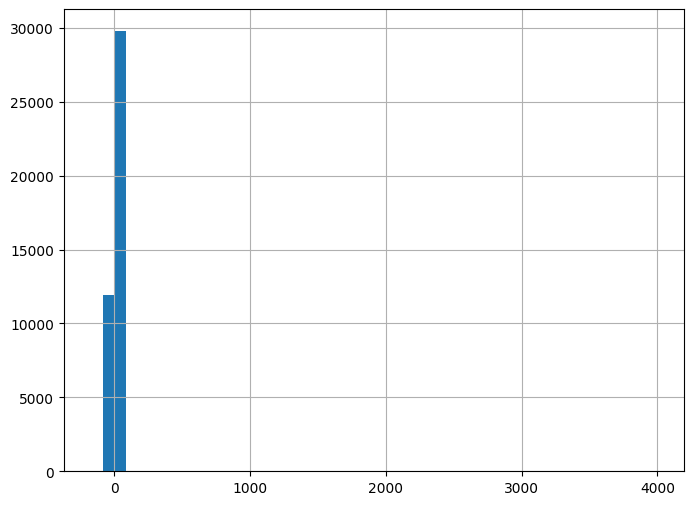

In [ ]:
diff_df.difference.hist(bins= 50, figsize=(8,6));

In [ ]:
diff_df.difference.describe()

,difference
count,41701.00
mean,4.47
std,26.05
min,-165.00
25%,0.00
50%,4.99
75%,6.99
max,3984.99


##Can all the differences be explained by shipping costs? If not, what are other plausible explanations?

##If there are differences that you can’t explain: what should you do with these orders?
There's a rule of thumb, that anything:

lower than the 25% quartile - (1.5 x interquartile range), or
higher than the 75% quartile + (1.5 x interquartile range)
is an outlier. Let's use this rule to try and exclude any corrupted data.

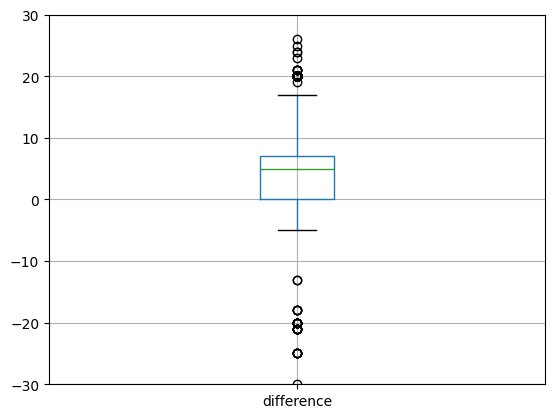

In [ ]:
# We know this rule from the boxplot
import matplotlib.pyplot as plt

ax = diff_df.boxplot("difference");
ax.set_ylim(-30, +30)
plt.show()

In [ ]:
# calculate the quartiles
Q1 = diff_df["difference"].quantile(0.25)
Q3 = diff_df["difference"].quantile(0.75)

Q1, Q3

(np.float64(0.0), np.float64(6.989999999999981))

In [ ]:
# calculate the interquartile range
IQR = Q3-Q1
IQR

np.float64(6.989999999999981)

In [ ]:
# lower boundary
Q1 - 1.5*IQR

np.float64(-10.484999999999971)

In [ ]:
# upper boundary
Q3 + 1.5*IQR

np.float64(17.47499999999995)

In [ ]:
# filter the DataFrame to include only "non-outliers"
diff_no_outliers_df = diff_df.loc[
    (diff_df["difference"] >= (Q1 - 1.5*IQR))
    &
    (diff_df["difference"] <= (Q3 + 1.5*IQR))
    ,
    :]

Let's look at the distribution again to see the effect of removing the outliers.

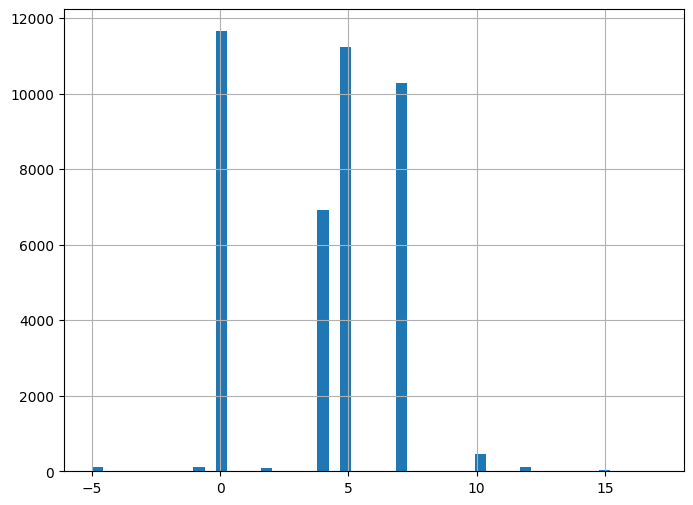

In [ ]:
diff_no_outliers_df.difference.hist(bins= 50, figsize=(8,6));

<Axes: >

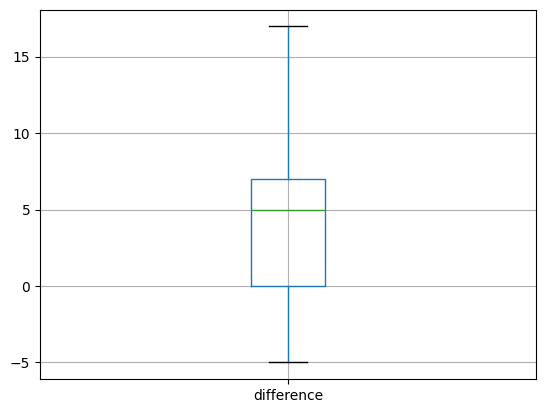

In [ ]:
diff_no_outliers_df.boxplot("difference")

This looks much more like what we would expect: a small difference, but nothing extreme.

Now we need to remove these orders with extreme differences from our orders_lines_merged DataFrame.

In [ ]:
normal_diff_list = diff_no_outliers_df["order_id"]

In [ ]:
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(normal_diff_list), :]
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(normal_diff_list), :]

In [ ]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(40985, 40985)

#CURRENT SITUATION

In [ ]:
orders_qu.shape

(40985, 4)

In [ ]:
orderlines_qu.shape

(53231, 7)

In [ ]:
products_qu.shape

(9992, 6)